(var_subsets)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 变量子集的向量自回归

```{index} single: Vector Autoregression; subsystems
```

```{index} single: Kalman Filter; and vector autoregressions
```

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的库之外，本讲座还需要以下库：

In [1]:
!pip install quantecon

## 概述

一个经济模型为一组变量 $Y_t$ 给出一个向量自回归。

计量经济学家通常只能观察到其中的*一部分*。

本讲座针对这种情形回答三个问题。

给定一个 $n \times 1$ 向量 $Y_t$ 的 $m$ 阶向量自回归，以及一个选择矩阵
$S_y$，它提取出一个 $n_y \times 1$ 的子向量 $y_t = S_y Y_t$：

1. $y_t$ 服从怎样的向量自回归？
2. 它的移动平均表示是什么？
3. 小系统中的新息与大系统中的新息之间有什么关系？

所有答案都来自 {doc}`卡尔曼滤波 <kalman_filter_var>`。

状态是有限阶向量自回归所需要的 $Y_t$ 的历史，观测则是子向量 $y_t$。

由于 $y_t$ 是状态的一个子向量，而不是关于状态的带噪信号，所以这是一个*没有*测量误差的状态空间系统。

主要结果是：

- $y_t$ 服从一个**无限阶**向量自回归，我们精确计算其系数，
- 小系统的新息 $a_t$ 是大系统新息 $\varepsilon_t$ 的**单侧分布滞后**，
- 该分布滞后在每一个滞后阶都有一个宽的系数矩阵，因此
  无法从 $y_t$ 的历史中恢复出 $\varepsilon_t$，
- 小系统的预测误差方差超过大系统的预测误差方差，超出的量我们也将计算出来。

我们还识别并验证了两种小向量自回归仍保持有限阶的特殊情形。

本讲座推广了以前在 {doc}`kalman_filter_var` 结尾处使用的实例。

让我们从导入开始。

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import quantecon as qe

plt.rcParams['figure.figsize'] = (10, 5)
np.set_printoptions(precision=4, suppress=True)

## 大系统

设 $Y_t$ 为 $n \times 1$ 的向量，并假设其服从 $m$ 阶向量自回归

$$
Y_{t+1} = A_1 Y_t + A_2 Y_{t-1} + \cdots + A_m Y_{t-m+1} + \varepsilon_{t+1},
\qquad
\mathbb{E}\, \varepsilon_t \varepsilon_t^\top = V ,
$$ (eq:vs_bigvar)

其中 $\{\varepsilon_t\}$ 是一个序列不相关的序列，满足
$\mathbb{E}[\varepsilon_{t+1} \mid Y_t, Y_{t-1}, \ldots] = 0$。

将 $m$ 期滞后堆叠为 $nm \times 1$ 的状态向量

$$
X_t = \begin{pmatrix} Y_t \\ Y_{t-1} \\ \vdots \\ Y_{t-m+1}\end{pmatrix} .
$$

于是 {eq}`eq:vs_bigvar` 变成一阶**伴随形式**

$$
X_{t+1} = A X_t + C \varepsilon_{t+1},
\qquad
A = \begin{pmatrix}
A_1 & A_2 & \cdots & A_{m-1} & A_m \\
I   & 0   & \cdots & 0       & 0 \\
0   & I   & \cdots & 0       & 0 \\
\vdots & & \ddots & & \vdots \\
0   & 0   & \cdots & I       & 0
\end{pmatrix},
\qquad
C = \begin{pmatrix} I_n \\ 0 \\ \vdots \\ 0 \end{pmatrix} .
$$ (eq:vs_companion)

我们用不带下标的 $A$ 表示伴随矩阵，用带下标的 $A_1, \ldots, A_m$
表示向量自回归系数矩阵。

设 $J = \begin{pmatrix} I_n & 0 & \cdots & 0\end{pmatrix}$ 为从状态中读取 $Y_t$ 的
$n \times nm$ 矩阵，使得 $Y_t = J X_t$ 且 $C = J^\top$。

我们假设 $A$ 的所有特征值都严格位于单位圆内，因此
$\{Y_t\}$ 是协方差平稳的。

## 小系统

计量经济学家观察到

$$
y_t = S_y Y_t = G X_t,
\qquad
G = S_y J ,
$$ (eq:vs_obs)

其中 $S_y$ 是 $n_y \times n$ 的矩阵，且 $n_y < n$。

通常 $S_y$ 是从 $Y_t$ 中挑选出 $n_y$ 个坐标，但下文并不要求如此，
因此也允许线性组合。

方程 {eq}`eq:vs_companion` 和 {eq}`eq:vs_obs` 构成了一个在 {doc}`kalman_filter_var` 中研究过的
状态空间系统，其中冲击加载为 $C$，观测矩阵为 $G$，测量误差协方差为

$$
R = 0 .
$$

该观测是*精确*的，但它是状态的严格子向量，因此
计量经济学家仍然面临一个滤波问题。

令 $\Sigma$ 求解稳态里卡蒂方程

$$
\Sigma = A \Sigma A^\top + C V C^\top
         - A \Sigma G^\top \bigl(G \Sigma G^\top\bigr)^{-1} G \Sigma A^\top
$$ (eq:vs_riccati)

对应的卡尔曼增益为

$$
K = A \Sigma G^\top \bigl(G \Sigma G^\top\bigr)^{-1} .
$$ (eq:vs_gain)

此处 $\Sigma$ 是 $X_t - \mathbb{E}[X_t \mid y^{t-1}]$ 的协方差矩阵。

```{note}
由于 $X_t$ 包含 $Y_t$ 的滞后项，而计量经济学家已经精确地观察到其中的 $S_y$ 分量，
所以 $\Sigma$ 是奇异的。

这是无害的。

卡尔曼增益 {eq}`eq:vs_gain` 所需要的是*新息*
协方差 $G \Sigma G^\top$ 非奇异，只要 $y_t$ 的任何线性组合
都不能被 $y^{t-1}$ 完全预测，这一点就成立。
```

小系统中的新息为

$$
a_t = y_t - \mathbb{E}[y_t \mid y^{t-1}] = G\bigl(X_t - \hat X_t\bigr),
\qquad
\Omega \equiv \mathbb{E}\, a_t a_t^\top = G \Sigma G^\top .
$$ (eq:vs_innov)

## 四种表示

### 沃尔德表示

{doc}`kalman_filter_var` 中导出的稳态新息表示是

$$
\hat X_{t+1} = A \hat X_t + K a_t,
\qquad
y_t = G \hat X_t + a_t .
$$ (eq:vs_innovrep)

向前求解 {eq}`eq:vs_innovrep`，得到用 $y_t$ 自身新息表示的移动平均表示，

$$
y_t = \sum_{h=0}^{\infty} \Psi_h\, a_{t-h},
\qquad
\Psi_0 = I_{n_y},
\qquad
\Psi_h = G A^{h-1} K \quad (h \geq 1) .
$$ (eq:vs_wold)

### 向量自回归

反过来向后求解 {eq}`eq:vs_innovrep`，得到

$$
y_t = \sum_{j=1}^{\infty} B_j\, y_{t-j} + a_t,
\qquad
B_j = G (A - KG)^{j-1} K .
$$ (eq:vs_var)

这是一个无限阶向量自回归，由于 $A - KG$ 的特征值
位于单位圆内，因此该级数收敛。

### 用大系统的新息表示小系统的新息

这正是激发本讲座的问题。

设 $e_t = X_t - \hat X_t$ 为滤波误差。

从状态方程 {eq}`eq:vs_companion` 中减去卡尔曼递推
$\hat X_{t+1} = A \hat X_t + K a_t$，并利用 $a_t = G e_t$，得到

$$
e_{t+1} = (A - KG) e_t + C \varepsilon_{t+1} .
$$ (eq:vs_error)

向后求解 {eq}`eq:vs_error` 并左乘 $G$，即可得到答案。

```{prf:proposition}
:label: vs_prop_innov

小系统的新息是大系统新息的单侧分布滞后

$$
a_t = \sum_{j=0}^{\infty} \Gamma_j\, \varepsilon_{t-j},
\qquad
\Gamma_j = G (A - KG)^j C ,
$$ (eq:vs_gamma)

其首项系数为

$$
\Gamma_0 = G C = S_y J J^\top = S_y .
$$
```

由于每一个 $\Gamma_j$ 都是 $n_y \times n$ 的矩阵，且 $n_y < n$，
从 $\{\varepsilon_t\}$ 到 $\{a_t\}$ 的映射没有逆映射。

知道 $y_t$ 的整个历史不足以恢复出 $\varepsilon_t$。

### 结构性移动平均

作为比较，迭代 {eq}`eq:vs_companion` 可以直接用大系统的新息表示 $y_t$，

$$
y_t = \sum_{j=0}^{\infty} \Phi_j\, \varepsilon_{t-j},
\qquad
\Phi_j = G A^j C .
$$ (eq:vs_phi)

### 包含过去冲击的预测误差

在 {eq}`eq:vs_gamma` 中把 $j = 0$ 这一项分离出来，并利用 $\Gamma_0 = S_y$，得到

$$
a_t = \underbrace{S_y \varepsilon_t}_{\text{完全信息预测误差}}
    \; + \;
      \underbrace{\sum_{j=1}^{\infty} \Gamma_j\, \varepsilon_{t-j}}_{t \text{ 之前实现的冲击}} .
$$ (eq:vs_split)

第一项正如它表面所示。

由于 $\mathbb{E}[\varepsilon_t \mid Y^{t-1}] = 0$，我们有
$y_t - \mathbb{E}[y_t \mid Y^{t-1}] = S_y \varepsilon_t$，所以 $S_y \varepsilon_t$
就是能观测到 $Y$ *整个*历史的人在预测 $y_t$ 时所犯的误差。

第二项值得停下来思考，因为乍一看它似乎是不可能的。

按照构造，$a_t$ 是一个预测误差，与 $t-1$ 期已知的一切正交。

然而 {eq}`eq:vs_split` 说 $a_t$ 加载在 $\varepsilon_{t-1},
\varepsilon_{t-2}, \ldots$ 上，而这些冲击在那时早已实现。

这两个事实是相容的，而且都是成立的：

$$
\mathbb{E}\, a_t\, \varepsilon_{t-j}^\top = \Gamma_j V \neq 0
\quad (j \geq 1),
\qquad \text{而} \qquad
\mathbb{E}\, a_t\, y_{t-k}^\top = 0
\quad (k \geq 1) .
$$ (eq:vs_orth)

其原因在于，过去的冲击是*大*系统的计量经济学家所知道的，而小系统的计量经济学家并不知道。

小系统计量经济学家的信息集是 $H(y^{t-1})$，即 $y_{t-1}, y_{t-2}, \ldots$ 的闭线性张成空间，
而 $\varepsilon_{t-j}$ 并不属于这个空间。

令 $P_{t-1}$ 表示投影到 $H(y^{t-1})$ 上的算子。

对 {eq}`eq:vs_split` 应用 $P_{t-1}$，利用 $P_{t-1} a_t = 0$ 和
$P_{t-1}\varepsilon_t = 0$，得到恒等式

$$
\sum_{j=1}^{\infty} \Gamma_j\, P_{t-1}\varepsilon_{t-j} = 0 .
$$ (eq:vs_pred)

因此 {eq}`eq:vs_split` 中的分布滞后只加载在小系统计量经济学家*尚未*了解到的过去冲击部分，

$$
a_t = S_y \varepsilon_t
    + \sum_{j=1}^{\infty} \Gamma_j
      \bigl(\varepsilon_{t-j} - P_{t-1}\varepsilon_{t-j}\bigr) .
$$ (eq:vs_unlearned)

如果你只关注的那个序列尚未把某个三个季度前发生的冲击完全揭示出来，那么这个冲击在今天仍然可以是新消息。

这正是滤波问题的全部内容所在，也是为什么 $\Omega$
会超过 $S_y V S_y^\top$ 的原因。

### 系数 $\Gamma_j$ 到底是什么

将移动平均表示 {eq}`eq:vs_phi` 代入自回归表示
{eq}`eq:vs_var`，并匹配 $\varepsilon_{t-k}$ 的系数，得到关于同一对象的第二个公式，

$$
\Gamma_k = \Phi_k - \sum_{j=1}^{k} B_j\, \Phi_{k-j} .
$$ (eq:vs_gamma_alt)

因此 $\Gamma_k$ 衡量的是小系统自身的自回归无法重现大系统 $k$ 阶滞后响应的程度。

值得写出 $k = 1$ 的情形。

由于 $\Phi_0 = S_y$，$\Phi_1 = G A C = S_y A_1$，

$$
\Gamma_1 = S_y A_1 - B_1 S_y .
$$ (eq:vs_gamma1)

假设 $S_y$ 是选择坐标的矩阵，并像之前一样将
$Y_t = (y_t^\top, \tilde y_t^\top)^\top$ 进行分块。

那么 $B_1 S_y$ 在属于被剔除变量的那些列上为零，所以
{eq}`eq:vs_gamma1` 变为

$$
\Gamma_1 = \begin{pmatrix} A_1^{yy} - B_1 & A_1^{y \tilde y}\end{pmatrix} .
$$ (eq:vs_gamma1_block)

$a_t$ 在上一期*被剔除*冲击上的加载恰好等于
$A_1^{y\tilde y}$，即被剔除变量进入被保留方程所经由的那个分块。

方程 {eq}`eq:vs_gamma1_block` 也预示了
{prf:ref}`vs_prop_blockexog`：分块外生性使得 $A_1^{y\tilde y} = 0$，
这将迫使 $B_1 = A_1^{yy}$，从而 $\Gamma_1 = 0$。

### 一个因式分解恒等式

表示 {eq}`eq:vs_wold`、{eq}`eq:vs_gamma` 和 {eq}`eq:vs_phi` 描述的是
同一个过程，因此如果记 $\Psi(z) = \sum_h \Psi_h z^h$，且对 $\Gamma$ 和 $\Phi$
也做类似定义，那么

$$
\Phi(z) = \Psi(z)\, \Gamma(z) .
$$ (eq:vs_factor)

方程 {eq}`eq:vs_factor` 说明，结构性移动平均算子可以分解为
小系统的沃尔德算子乘以新息映射。

这是对上述一切内容的一个严格的数值检验，我们也把它作为一种检验方式来使用。

在各阶滞后处匹配方差，也可以得到

$$
\Omega = \sum_{j=0}^{\infty} \Gamma_j V \Gamma_j^\top
       = S_y V S_y^\top + \sum_{j=1}^{\infty} \Gamma_j V \Gamma_j^\top .
$$ (eq:vs_varloss)

第二个求和中的每一项都是半正定的，因此

$$
\Omega \succeq S_y V S_y^\top .
$$

小系统的一步预测误差方差绝不会小于大系统中对应分块的预测误差方差，而
{eq}`eq:vs_varloss` 精确地说明了到底损失了多少。

## 两种没有信息损失的情形

```{prf:proposition}
:label: vs_prop_full

如果 $S_y = I_n$，那么 $\Gamma_0 = I_n$ 且对 $j \geq 1$ 有 $\Gamma_j = 0$，因此
$a_t = \varepsilon_t$，且 {eq}`eq:vs_var` 就退化为原始的 $m$ 阶
向量自回归 {eq}`eq:vs_bigvar`。
```

此时没有任何信息被隐藏，因此沃尔德新息*就是*结构新息。

第二种情形更有趣。

将 $Y_t = (y_t^\top, \tilde y_t^\top)^\top$ 分块，相应地

$$
A_k = \begin{pmatrix} A_k^{yy} & A_k^{y\tilde y} \\
                      A_k^{\tilde y y} & A_k^{\tilde y \tilde y}\end{pmatrix},
\qquad k = 1, \ldots, m .
$$

```{prf:proposition}
:label: vs_prop_blockexog

假设 $y_t$ 是**分块外生的**，即对所有 $k$ 都有 $A_k^{y\tilde y} = 0$，
这意味着在 $y$ 的方程中不出现被剔除变量的任何滞后项。

那么对 $j \geq 1$ 有 $\Gamma_j = 0$，$a_t = S_y \varepsilon_t$，
$\Omega = S_y V S_y^\top$，且 $y_t$ 服从有限的 $m$ 阶向量自回归

$$
y_t = \sum_{k=1}^{m} A_k^{yy}\, y_{t-k} + a_t .
$$
```

```{prf:proof}
分块外生性使得 {eq}`eq:vs_bigvar` 中 $y$ 那些行可以写成
$y_{t+1} = \sum_k A_k^{yy} y_{t+1-k} + S_y \varepsilon_{t+1}$。

方程右边只涉及 $y$ 的滞后项，而 $S_y \varepsilon_{t+1}$
与整个历史 $Y^t$ 正交，因而也与 $y^t$ 正交。

所以这*就是* $y_{t+1}$ 在 $y^t$ 上的投影，从而将其识别为
沃尔德表示。
```

请注意 {prf:ref}`vs_prop_blockexog` *并不*要求什么：$V$ 不必是分块对角的。

$\varepsilon^y$ 与 $\varepsilon^{\tilde y}$ 之间存在同期相关是可以的。

对于一个被剔除的变量是否会损害向量自回归而言，重要的是格兰杰因果性，
而不是同期相关性。

## 代码

下面的类将上述内容全部打包在一起。

In [3]:
class VARSubsystem:
    """
    A VAR for Y and the implied representations for a subvector y = S_y Y.

        Y[t+1] = A_1 Y[t] + ... + A_m Y[t-m+1] + eps[t+1],  E eps eps' = V
        y[t]   = S_y Y[t]

    Parameters
    ----------
    A_list : list of (n, n) arrays, the VAR coefficient matrices A_1, ..., A_m
    V      : (n, n) array, covariance matrix of eps
    S_y    : (n_y, n) selector matrix
    """

    def __init__(self, A_list, V, S_y):
        self.A_list = [np.atleast_2d(np.asarray(a, dtype=float)) for a in A_list]
        self.V = np.atleast_2d(np.asarray(V, dtype=float))
        self.S_y = np.atleast_2d(np.asarray(S_y, dtype=float))
        n, m = self.A_list[0].shape[0], len(self.A_list)
        self.n, self.m, self.n_y = n, m, self.S_y.shape[0]

        # companion form
        self.A = np.zeros((n * m, n * m))
        self.A[:n] = np.hstack(self.A_list)
        if m > 1:
            self.A[n:, :n * (m - 1)] = np.eye(n * (m - 1))
        self.J = np.zeros((n, n * m))
        self.J[:, :n] = np.eye(n)
        self.C = self.J.T
        self.G = self.S_y @ self.J
        self.Q = self.C @ self.V @ self.C.T
        self._Sigma = self._K = None

    def companion_eigenvalues(self):
        return np.linalg.eigvals(self.A)

    def stationary_filter(self):
        """Steady-state (Sigma, K) from the Riccati equation with R = 0."""
        if self._Sigma is None:
            A, G = self.A, self.G
            R = np.zeros((self.n_y, self.n_y))
            Sigma = qe.solve_discrete_riccati(A.T, G.T, self.Q, R)
            Omega = G @ Sigma @ G.T
            self._Sigma = Sigma
            self._K = A @ Sigma @ G.T @ np.linalg.inv(Omega)
        return self._Sigma, self._K

    def innovation_cov(self):
        """Omega = E a a', the one-step forecast error covariance of y."""
        Sigma, _ = self.stationary_filter()
        return self.G @ Sigma @ self.G.T

    def wold(self, h_max=20):
        """Psi[h] in y[t] = sum_h Psi[h] a[t-h]; Psi[0] = I."""
        _, K = self.stationary_filter()
        Psi = np.empty((h_max + 1, self.n_y, self.n_y))
        Psi[0], P = np.eye(self.n_y), np.eye(self.A.shape[0])
        for h in range(1, h_max + 1):
            Psi[h] = self.G @ P @ K
            P = P @ self.A
        return Psi

    def var_coefficients(self, h_max=20):
        """B[j-1] in y[t] = sum_j B[j] y[t-j] + a[t], for j = 1, ..., h_max."""
        _, K = self.stationary_filter()
        M = self.A - K @ self.G
        B, P = np.empty((h_max, self.n_y, self.n_y)), np.eye(self.A.shape[0])
        for j in range(h_max):
            B[j] = self.G @ P @ K
            P = P @ M
        return B

    def innovation_map(self, h_max=20):
        """Gamma[j] in a[t] = sum_j Gamma[j] eps[t-j]."""
        _, K = self.stationary_filter()
        M = self.A - K @ self.G
        Gamma, P = np.empty((h_max + 1, self.n_y, self.n)), np.eye(self.A.shape[0])
        for j in range(h_max + 1):
            Gamma[j] = self.G @ P @ self.C
            P = P @ M
        return Gamma

    def structural_ma(self, h_max=20):
        """Phi[j] in y[t] = sum_j Phi[j] eps[t-j]."""
        Phi, P = np.empty((h_max + 1, self.n_y, self.n)), np.eye(self.A.shape[0])
        for j in range(h_max + 1):
            Phi[j] = self.G @ P @ self.C
            P = P @ self.A
        return Phi

    def simulate(self, T, seed=0, burn=200):
        """Simulate Y and the innovations eps that generated it."""
        rng = np.random.default_rng(seed)
        L = np.linalg.cholesky(self.V)
        eps = rng.standard_normal((T + burn, self.n)) @ L.T
        X, Y = np.zeros(self.n * self.m), np.zeros((T + burn, self.n))
        for t in range(T + burn):
            X = self.A @ X + self.C @ eps[t]
            Y[t] = self.J @ X
        return Y[burn:], eps[burn:]

    def filter_innovations(self, y_path):
        """Recover a[t] from observed y by running the steady-state filter."""
        _, K = self.stationary_filter()
        x_hat = np.zeros(self.A.shape[0])
        a = np.empty((len(y_path), self.n_y))
        for t in range(len(y_path)):
            a[t] = y_path[t] - self.G @ x_hat
            x_hat = self.A @ x_hat + K @ a[t]
        return a


def convolve(Psi, Gamma, h_max):
    """(Psi * Gamma)[h] = sum_{k=0}^{h} Psi[k] Gamma[h-k]."""
    out = np.zeros((h_max + 1, Psi.shape[1], Gamma.shape[2]))
    for h in range(h_max + 1):
        for k in range(h + 1):
            out[h] += Psi[k] @ Gamma[h - k]
    return out

下面这个单一的例程收集了我们希望针对每个例子查看的各种诊断信息。

In [4]:
def report(model, h_max=30, label=''):
    """Print the identities that every subsystem must satisfy."""
    Sigma, K = model.stationary_filter()
    A, G, V = model.A, model.G, model.V
    resid = Sigma - (A @ Sigma @ A.T + model.Q
                     - A @ Sigma @ G.T @ np.linalg.inv(G @ Sigma @ G.T)
                       @ G @ Sigma @ A.T)
    Psi = model.wold(h_max)
    Gamma = model.innovation_map(h_max)
    Phi = model.structural_ma(h_max)
    Omega, Vy = model.innovation_cov(), model.S_y @ V @ model.S_y.T

    print(f'--- {label} (n = {model.n}, m = {model.m}, n_y = {model.n_y})')
    print(f'  max |eig| of companion A      {np.max(abs(model.companion_eigenvalues())):.6f}')
    print(f'  max |eig| of A - KG           {np.max(abs(np.linalg.eigvals(A - K @ G))):.6f}')
    print(f'  Riccati residual              {np.abs(resid).max():.2e}')
    print(f'  |Gamma[0] - S_y|              {np.abs(Gamma[0] - model.S_y).max():.2e}')
    print(f'  |Phi - Psi * Gamma|           '
          f'{np.abs(convolve(Psi, Gamma, h_max) - Phi).max():.2e}')
    Gamma_long = model.innovation_map(300)      # the sum in (SS) is infinite
    print(f'  |Omega - sum Gamma V Gamma\'|  '
          f'{np.abs(Omega - sum(Gamma_long[j] @ V @ Gamma_long[j].T for j in range(301))).max():.2e}')
    print(f'  max |Gamma[j]|, j >= 1        {np.abs(Gamma[1:]).max():.3e}')
    print(f'  det Omega / det S_y V S_y\'    '
          f'{np.linalg.det(Omega) / np.linalg.det(Vy):.4f}')
    return Psi, Gamma, Phi

## 例1：一个二元向量自回归 VAR(2)

两个可观测序列 $r_t$ 和 $z_t$ 服从向量自回归 VAR(2)

$$
\begin{pmatrix} r_{t+1} \\ z_{t+1}\end{pmatrix}
= A_1 \begin{pmatrix} r_t \\ z_t \end{pmatrix}
+ A_2 \begin{pmatrix} r_{t-1} \\ z_{t-1}\end{pmatrix}
+ \varepsilon_{t+1},
$$

其中

$$
A_1 = \begin{pmatrix} 0.80 & 0.75 \\ 0 & 0.75 \end{pmatrix},
\qquad
A_2 = \begin{pmatrix} 0.05 & -0.72 \\ 0 & 0.20 \end{pmatrix},
\qquad
V = I_2 .
$$

请注意 $z$ 是分块外生的：其方程中不包含 $r$ 的滞后项。

但 $r$ 却*不是*，因为 $z$ 以两个滞后项都进入了 $r$ 的方程。

因此剔除 $z$ 应当是重要的，而剔除 $r$ 则不应有影响。

In [5]:
A1 = np.array([[0.80,  0.75],
               [0.00,  0.75]])
A2 = np.array([[0.05, -0.72],
               [0.00,  0.20]])
V2 = np.eye(2)

S_both = np.eye(2)                    # observe (r, z)
S_r    = np.array([[1.0, 0.0]])       # observe r only
S_z    = np.array([[0.0, 1.0]])       # observe z only

mod_both = VARSubsystem([A1, A2], V2, S_both)
mod_r    = VARSubsystem([A1, A2], V2, S_r)
mod_z    = VARSubsystem([A1, A2], V2, S_z)

Psi_both, Gam_both, _ = report(mod_both, label='observe r and z')
print()
Psi_r, Gam_r, _ = report(mod_r, label='observe r only')
print()
Psi_z, Gam_z, _ = report(mod_z, label='observe z only')

--- observe r and z (n = 2, m = 2, n_y = 2)
  max |eig| of companion A      0.958631
  max |eig| of A - KG           0.000000
  Riccati residual              0.00e+00
  |Gamma[0] - S_y|              0.00e+00
  |Phi - Psi * Gamma|           0.00e+00
  |Omega - sum Gamma V Gamma'|  0.00e+00
  max |Gamma[j]|, j >= 1        0.000e+00
  det Omega / det S_y V S_y'    1.0000

--- observe r only (n = 2, m = 2, n_y = 1)
  max |eig| of companion A      0.958631
  max |eig| of A - KG           0.959007
  Riccati residual              8.88e-16
  |Gamma[0] - S_y|              0.00e+00
  |Phi - Psi * Gamma|           1.67e-16
  |Omega - sum Gamma V Gamma'|  1.78e-15
  max |Gamma[j]|, j >= 1        7.500e-01
  det Omega / det S_y V S_y'    1.5786

--- observe z only (n = 2, m = 2, n_y = 1)
  max |eig| of companion A      0.958631
  max |eig| of A - KG           0.858258
  Riccati residual              4.44e-16
  |Gamma[0] - S_y|              0.00e+00
  |Phi - Psi * Gamma|           0.00e+00
  |Omega 

每个恒等式都在机器精度下成立。

这三种情形的差异恰好与命题的预测一致。

同时观测两个变量时，对 $j \geq 1$ 有 $\Gamma_j = 0$，因此
$a_t = \varepsilon_t$，这正是 {prf:ref}`vs_prop_full` 所要求的。

只观测 $z$（它是分块外生的）时，对 $j \geq 1$ 也有 $\Gamma_j = 0$，
因此 $a_t = \varepsilon_{z,t}$，这正是 {prf:ref}`vs_prop_blockexog`
所要求的。

只观测 $r$ 的情形则不同。

此时对 $j \geq 1$ 有 $\Gamma_j \neq 0$，预测误差方差之比揭示了只观测 $r$
的计量经济学家所损失的信息量。

In [6]:
print('observe r only:')
print(f'  Omega           = {mod_r.innovation_cov()[0, 0]:.4f}')
print(f'  S_y V S_y\'      = {(S_r @ V2 @ S_r.T)[0, 0]:.4f}')
print('\n  Gamma[j] for j = 0, ..., 5 (rows: response of a to eps_r, eps_z)')
print(Gam_r[:6, 0, :])

observe r only:
  Omega           = 1.5786
  S_y V S_y'      = 1.0000

  Gamma[j] for j = 0, ..., 5 (rows: response of a to eps_r, eps_z)
[[ 1.      0.    ]
 [ 0.0769  0.75  ]
 [-0.0097 -0.0998]
 [ 0.0017  0.0125]
 [ 0.0002 -0.0023]
 [ 0.0004 -0.0003]]


预测误差方差比 $V_{11}$ 大出超过百分之五十。

多出来的那部分方差，完全可以归因于计量经济学家只能通过其对 $r$ 的影响间接观测到的过去 $\varepsilon_z$ 冲击。

### 子系统的向量自回归

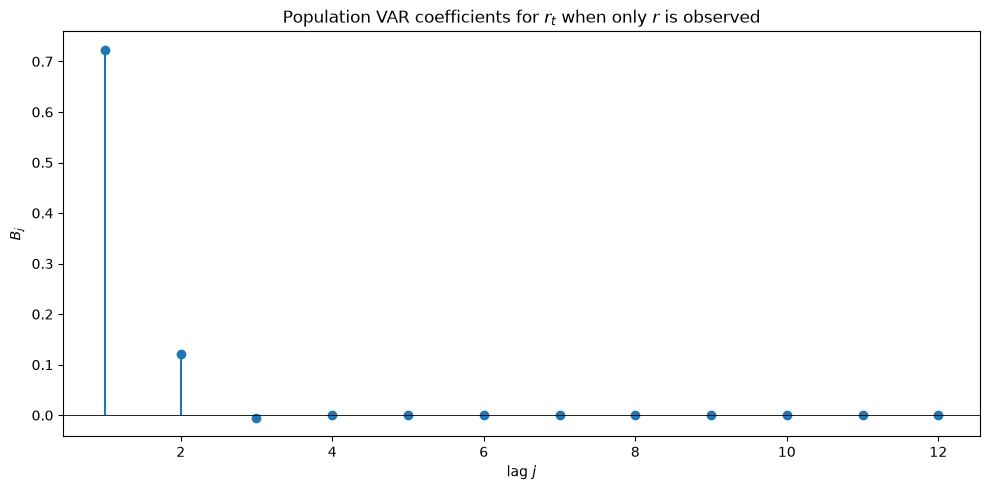

B_1, ..., B_6: [ 0.7231  0.1212 -0.0056  0.0007 -0.0001 -0.    ]

for comparison, A_1[0,0] and A_2[0,0]: 0.8 0.05


In [7]:
B_r = mod_r.var_coefficients(12)

fig, ax = plt.subplots()
ax.stem(np.arange(1, 13), B_r[:, 0, 0], basefmt=' ')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('lag $j$')
ax.set_ylabel('$B_j$')
ax.set_title(r'Population VAR coefficients for $r_t$ when only $r$ is observed')
fig.tight_layout()
plt.show()

print('B_1, ..., B_6:', np.round(B_r[:6, 0, 0], 5))
print('\nfor comparison, A_1[0,0] and A_2[0,0]:', A1[0, 0], A2[0, 0])

只用 $r$ 建立的无限阶向量自回归主要由两个滞后项主导，但这两个系数
都不等于二元系统中对应的系数。

剔除 $z$ 并不只是简单地删去向量自回归中 $z$ 的那些列，而是改变了剩下的东西。

### 沃尔德脉冲响应

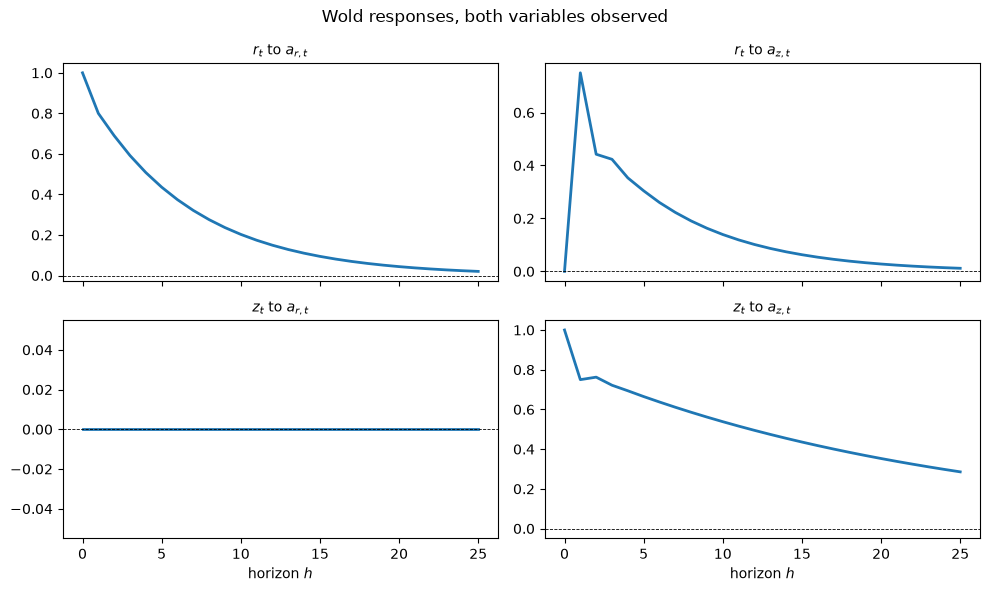

In [8]:
H = 25
h = np.arange(H + 1)
Psi_both = mod_both.wold(H)

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
names, shocks = [r'$r_t$', r'$z_t$'], [r'$a_{r,t}$', r'$a_{z,t}$']
for i in range(2):
    for j in range(2):
        axes[i, j].plot(h, Psi_both[:, i, j], lw=2)
        axes[i, j].axhline(0, color='k', lw=0.6, ls='--')
        axes[i, j].set_title(f'{names[i]} to {shocks[j]}', fontsize=10)
        if i == 1:
            axes[i, j].set_xlabel('horizon $h$')
fig.suptitle('Wold responses, both variables observed')
fig.tight_layout()
plt.show()

由于此时 $a_t = \varepsilon_t$，这些沃尔德响应与二元向量自回归的结构响应一致。

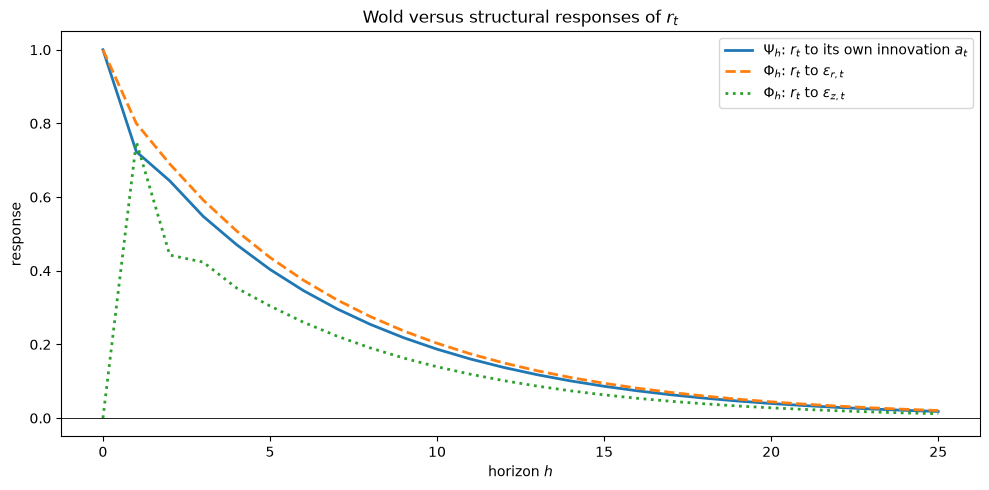

In [9]:
Psi_r = mod_r.wold(H)
Phi_r = mod_r.structural_ma(H)

fig, ax = plt.subplots()
ax.plot(h, Psi_r[:, 0, 0], lw=2, label=r'$\Psi_h$: $r_t$ to its own innovation $a_t$')
ax.plot(h, Phi_r[:, 0, 0], lw=2, ls='--',
        label=r'$\Phi_h$: $r_t$ to $\varepsilon_{r,t}$')
ax.plot(h, Phi_r[:, 0, 1], lw=2, ls=':',
        label=r'$\Phi_h$: $r_t$ to $\varepsilon_{z,t}$')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('horizon $h$')
ax.set_ylabel('response')
ax.set_title(r'Wold versus structural responses of $r_t$')
ax.legend()
fig.tight_layout()
plt.show()

沃尔德响应针对的是 $a_t$，它既不是对某一个结构冲击的响应，也不是对另一个的响应。

它是两者的混合，而 {eq}`eq:vs_factor` 恰好说明了这种混合是如何发生的。

### 通过模拟检验新息映射

命题 {prf:ref}`vs_prop_innov` 是关于总体对象的一个陈述。

我们通过比较从观测到的 $r$ 序列中由卡尔曼滤波提取的新息与由产生该序列的冲击
构建的分布滞后 $\sum_j \Gamma_j \varepsilon_{t-j}$，在一段较长的模拟样本上检验这一命题。

In [10]:
T = 100_000
Y_sim, eps_sim = mod_r.simulate(T, seed=1)
y_sim = Y_sim @ S_r.T

a_filtered = mod_r.filter_innovations(y_sim)

J_lag = 400          # the distributed lag is infinite, so truncate generously
Gam_long = mod_r.innovation_map(J_lag)
a_theory = np.zeros_like(a_filtered)
for j in range(J_lag + 1):
    a_theory[j:] += eps_sim[:T - j] @ Gam_long[j].T

burn = J_lag + 1
print(f'correlation of the two series   '
      f'{np.corrcoef(a_filtered[burn:, 0], a_theory[burn:, 0])[0, 1]:.8f}')
print(f'max absolute difference         '
      f'{np.abs(a_filtered[burn:] - a_theory[burn:]).max():.2e}')
print(f'sample variance of a            {a_filtered[burn:, 0].var():.4f}')
print(f'population Omega                {mod_r.innovation_cov()[0, 0]:.4f}')
print(f'sample corr(a_t, a_(t-1))       '
      f'{np.corrcoef(a_filtered[burn + 1:, 0], a_filtered[burn:-1, 0])[0, 1]:.4f}')

correlation of the two series   1.00000000
max absolute difference         6.45e-10
sample variance of a            1.5706
population Omega                1.5786
sample corr(a_t, a_(t-1))       -0.0048


两种构造出来的 $a_t$ 在截断分布滞后所允许的精度范围内是一致的，$a_t$
的样本方差与 $\Omega$ 相符，且 $a_t$ 是序列不相关的。

### 两个正交性事实

现在我们通过对模拟数据进行两次回归，直接检验 {eq}`eq:vs_orth`。

第一次将 $a_t$ 回归到当期和滞后的*结构*冲击上，而这些冲击是小系统的计量经济学家所看不到的。

第二次将 $a_t$ 回归到滞后的*观测值*上，而这才是小系统的计量经济学家能够看到的全部信息。

In [11]:
P_lags = 4
Z_eps = np.column_stack([eps_sim[P_lags - l:T - l] for l in range(P_lags + 1)])
target = a_filtered[P_lags:, 0]
b_eps = np.linalg.lstsq(Z_eps, target, rcond=None)[0].reshape(P_lags + 1, 2)
fit = Z_eps @ b_eps.ravel()
r2_eps = 1 - ((target - fit) ** 2).sum() / target.var() / len(target)

print('OLS of a_t on eps_t, ..., eps_{t-4}:')
print(b_eps)
print('population Gamma_0, ..., Gamma_4:')
print(Gam_long[:P_lags + 1, 0, :])
print(f'max discrepancy {np.abs(b_eps - Gam_long[:P_lags + 1, 0, :]).max():.2e}')
print(f'R^2 = {r2_eps:.6f}')

OLS of a_t on eps_t, ..., eps_{t-4}:
[[ 1.     -0.    ]
 [ 0.0769  0.75  ]
 [-0.0097 -0.0998]
 [ 0.0017  0.0125]
 [ 0.0002 -0.0023]]
population Gamma_0, ..., Gamma_4:
[[ 1.      0.    ]
 [ 0.0769  0.75  ]
 [-0.0097 -0.0998]
 [ 0.0017  0.0125]
 [ 0.0002 -0.0023]]
max discrepancy 1.64e-05
R^2 = 0.999996


In [12]:
Q_lags = 8
Z_y = np.column_stack([y_sim[Q_lags - l - 1:T - l - 1, 0] for l in range(Q_lags)])
tgt = a_filtered[Q_lags:, 0]
b_y = np.linalg.lstsq(Z_y, tgt, rcond=None)[0]
resid = tgt - Z_y @ b_y
r2_y = 1 - (resid ** 2).sum() / tgt.var() / len(tgt)

print('OLS of a_t on y_{t-1}, ..., y_{t-8}:')
print(np.round(b_y, 5))
print(f'R^2 = {r2_y:.6f}')

OLS of a_t on y_{t-1}, ..., y_{t-8}:
[-0.0046  0.0044 -0.0015  0.001   0.0018 -0.0063  0.0055 -0.0024]
R^2 = 0.000056


第一个回归恢复了 $\Gamma_j$，几乎完美拟合，唯一微小的偏差仅来自
将分布滞后截断为四阶所带来的误差。

所以 $a_t$ 确实是由回溯到 $t$ 之前的冲击构造出来的。

第二个回归则几乎解释不了任何东西，这证实了 $a_t$ 仍然与小系统计量经济学家的信息集正交。

我们可以通过询问小系统计量经济学家究竟已经从每一个过去冲击中了解到多少信息，来理解这一点为什么成立。

In [13]:
print('R^2 from projecting a structural shock on y_{t-1}, ..., y_{t-8}')
for lag in [0, 1, 2, 3]:
    r2s = []
    for k in range(2):
        shock = eps_sim[Q_lags - lag:T - lag, k]
        c = np.linalg.lstsq(Z_y, shock, rcond=None)[0]
        e = shock - Z_y @ c
        r2s.append(1 - (e ** 2).sum() / shock.var() / len(shock))
    print(f'   eps_(t-{lag}):   eps_r {r2s[0]:6.4f}    eps_z {r2s[1]:6.4f}')

R^2 from projecting a structural shock on y_{t-1}, ..., y_{t-8}
   eps_(t-0):   eps_r 0.0000    eps_z 0.0001
   eps_(t-1):   eps_r 0.6314    eps_z 0.0001
   eps_(t-2):   eps_r 0.6351    eps_z 0.3561
   eps_(t-3):   eps_r 0.6352    eps_z 0.3624


当期冲击 $\varepsilon_t$ 完全无法从 $y^{t-1}$ 中被预测出来，这是必然的。

而两期或更多期以前的冲击则在很大程度上已经被了解到了。

其中最有意思的一行是 $\varepsilon_{t-1}$：它的 $r$ 分量在很大程度上是已知的，
而它的 $z$ 分量则*完全*未知，这是因为 $z_{t-1}$ 要经过一期滞后才能影响到 $r$，
所以在 $y^{t-1}$ 中还没有以任何方式体现出来。

这正是为什么 {eq}`eq:vs_gamma1_block` 给出 $a_t$ 在
$\varepsilon_{z,t-1}$ 上的加载恰好等于完整的结构系数
$A_1^{y\tilde y} = 0.75$，而它在 $\varepsilon_{r,t-1}$ 上的加载则只是
小得多的残差 $A_1^{yy} - B_1$。

In [14]:
B1 = mod_r.var_coefficients(1)[0]
print(f'Gamma_1                  = {Gam_long[1, 0, :]}')
print(f'[A1[0,0] - B_1,  A1[0,1]] = '
      f'[{A1[0, 0] - B1[0, 0]:.4f}, {A1[0, 1]:.4f}]')

Phi_r = mod_r.structural_ma(6)
B_r6 = mod_r.var_coefficients(6)
recursion = np.array([Phi_r[k] - sum(B_r6[j - 1] @ Phi_r[k - j]
                                     for j in range(1, k + 1))
                      for k in range(7)])
print(f'\nmax |Gamma_k - (Phi_k - sum_j B_j Phi_(k-j))| = '
      f'{np.abs(recursion - Gam_long[:7]).max():.2e}')

Gamma_1                  = [0.0769 0.75  ]
[A1[0,0] - B_1,  A1[0,1]] = [0.0769, 0.7500]

max |Gamma_k - (Phi_k - sum_j B_j Phi_(k-j))| = 1.11e-16


## 例2：被剔除的利率变量

现在考虑一个关于产出增长率 $g_t$、通货膨胀 $\pi_t$ 和利率
$i_t$ 的三元向量自回归 VAR(1)，计量经济学家从中剔除了 $i_t$。

我们对比两个系数矩阵，二者的*唯一*区别在于利率是否反馈到 $g$ 和 $\pi$ 上。

$$
A_1^{\text{exog}} =
\begin{pmatrix}
0.60 & 0.10 & 0.00 \\
0.15 & 0.55 & 0.00 \\
0.30 & 0.40 & 0.70
\end{pmatrix},
\qquad
A_1^{\text{fb}} =
\begin{pmatrix}
0.60 & 0.10 & -0.35 \\
0.15 & 0.55 &  0.25 \\
0.30 & 0.40 &  0.70
\end{pmatrix} .
$$

两种情形下的冲击协方差矩阵 $V$ 相同，而且它*不是*对角矩阵，因此利率新息
与其他两个新息之间存在同期相关关系。

In [15]:
V3 = np.array([[0.36, 0.05, 0.02],
               [0.05, 0.25, 0.06],
               [0.02, 0.06, 0.16]])
S_gpi = np.array([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0]])

A_exog = np.array([[0.60, 0.10, 0.00],
                   [0.15, 0.55, 0.00],
                   [0.30, 0.40, 0.70]])
A_fb = np.array([[0.60, 0.10, -0.35],
                 [0.15, 0.55,  0.25],
                 [0.30, 0.40,  0.70]])

mod_exog = VARSubsystem([A_exog], V3, S_gpi)
mod_fb = VARSubsystem([A_fb], V3, S_gpi)

_, Gam_exog, _ = report(mod_exog, label='i is block exogenous')
print()
_, Gam_fb, _ = report(mod_fb, label='i feeds back')

--- i is block exogenous (n = 3, m = 1, n_y = 2)
  max |eig| of companion A      0.700000
  max |eig| of A - KG           0.700000
  Riccati residual              5.55e-17
  |Gamma[0] - S_y|              0.00e+00
  |Phi - Psi * Gamma|           2.78e-17
  |Omega - sum Gamma V Gamma'|  0.00e+00
  max |Gamma[j]|, j >= 1        1.110e-16
  det Omega / det S_y V S_y'    1.0000

--- i feeds back (n = 3, m = 1, n_y = 2)
  max |eig| of companion A      0.792688
  max |eig| of A - KG           0.558938
  Riccati residual              1.11e-16
  |Gamma[0] - S_y|              0.00e+00
  |Phi - Psi * Gamma|           5.55e-17
  |Omega - sum Gamma V Gamma'|  1.11e-16
  max |Gamma[j]|, j >= 1        3.500e-01
  det Omega / det S_y V S_y'    1.1614


即使冲击相关，分块外生情形也完全符合 {prf:ref}`vs_prop_blockexog`
所要求的行为。

而反馈情形则不然。

In [16]:
print('block exogenous: B_1 versus the (g, pi) block of A_1')
print(mod_exog.var_coefficients(3)[0])
print(A_exog[:2, :2])
print(f'  max |B_j| for j >= 2: {np.abs(mod_exog.var_coefficients(12)[1:]).max():.2e}')

print('\nfeedback: B_1 versus the (g, pi) block of A_1')
print(mod_fb.var_coefficients(3)[0])
print(A_fb[:2, :2])
print(f'  max |B_j| for j >= 2: {np.abs(mod_fb.var_coefficients(12)[1:]).max():.4f}')

block exogenous: B_1 versus the (g, pi) block of A_1
[[0.6  0.1 ]
 [0.15 0.55]]
[[0.6  0.1 ]
 [0.15 0.55]]
  max |B_j| for j >= 2: 6.66e-17

feedback: B_1 versus the (g, pi) block of A_1
[[ 0.643  -0.0373]
 [ 0.1193  0.648 ]]
[[0.6  0.1 ]
 [0.15 0.55]]
  max |B_j| for j >= 2: 0.1455


在分块外生的情形下，子系统向量自回归*恰好*就是大向量自回归中对应的那一分块，
且只有一阶滞后。

在反馈情形下，一阶滞后系数被扭曲，同时还出现了更高阶的项。

值得注意的是，滞后通货膨胀在产出增长方程中的系数所受到的影响：大系统中的一个正数，
在子系统中变成了负数。

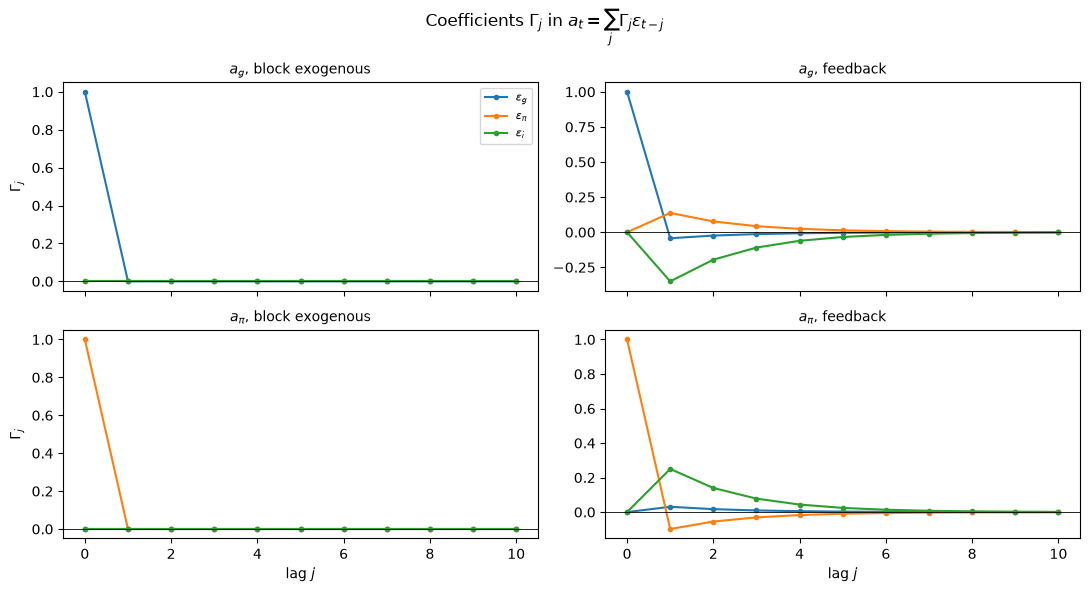

In [17]:
J_max = 10
labels = [r'$\varepsilon_g$', r'$\varepsilon_\pi$', r'$\varepsilon_i$']
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for col, (Gam, ttl) in enumerate([(Gam_exog, 'block exogenous'),
                                  (Gam_fb, 'feedback')]):
    for row, obs in enumerate([r'$a_g$', r'$a_\pi$']):
        ax = axes[row, col]
        for k in range(3):
            ax.plot(np.arange(J_max + 1), Gam[:J_max + 1, row, k],
                    marker='o', ms=3, lw=1.5, label=labels[k])
        ax.axhline(0, color='k', lw=0.6)
        ax.set_title(f'{obs}, {ttl}', fontsize=10)
        if row == 1:
            ax.set_xlabel('lag $j$')
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
axes[0, 0].set_ylabel(r'$\Gamma_j$')
axes[1, 0].set_ylabel(r'$\Gamma_j$')
fig.suptitle(r'Coefficients $\Gamma_j$ in $a_t = \sum_j \Gamma_j \varepsilon_{t-j}$')
fig.tight_layout()
plt.show()

在左侧一列中，只有 $j = 0$ 处的系数非零，且它们恰好等于 $S_y$ 的各行。

而在右侧一列中，被剔除的利率冲击 $\varepsilon_i$ 在每一个滞后阶都渗漏进了
观测到的新息之中。

## 总结

对 $Y_t$ 的一个有限阶向量自回归，对任何子向量 $y_t = S_y Y_t$ 都蕴含着一个
无限阶向量自回归，其系数 $B_j = G(A - KG)^{j-1}K$ 来自
针对伴随系统的稳态卡尔曼滤波。

小系统的新息是大系统新息的单侧分布滞后
$a_t = \sum_j \Gamma_j \varepsilon_{t-j}$，其中
$\Gamma_j = G(A - KG)^j C$ 且 $\Gamma_0 = S_y$。

由于 $\Gamma_j$ 是一个宽矩阵，该映射无法求逆，这正是子系统向量自回归
信息缺失的精确表述。

这一代价的大小由 $\Omega - S_y V S_y^\top = \sum_{j \geq 1} \Gamma_j V \Gamma_j^\top$ 来度量。

当一切都被观测到时，这一代价为零；而当被保留的分块是分块外生的时候，
代价也同样为零，此时子系统向量自回归恰好等于原系统中对应的那一分块。

## 练习

```{exercise-start}
:label: vs_ex1
```

以例2中的三元系统为基础，通过写出

$$
A_1(\theta) = A_1^{\text{exog}} + \theta \begin{pmatrix} 0 & 0 & -0.35 \\
0 & 0 & 0.25 \\ 0 & 0 & 0 \end{pmatrix} .
$$

将利率对 $(g, \pi)$ 的反馈强度置于你的控制之下。

对 $\theta$ 在从 $0$ 到 $1.5$ 的网格上取值，画出

1. $\det \Omega / \det(S_y V S_y^\top)$，即剔除 $i_t$ 所损失的信息量，
2. $\max_{j \geq 1} |\Gamma_j|$，即过去冲击渗漏进观测新息中的大小。

解释你在 $\theta = 0$ 处所发现的图形形状。

```{exercise-end}
```

```{solution-start} vs_ex1
:class: dropdown
```

下面给出一种解法：

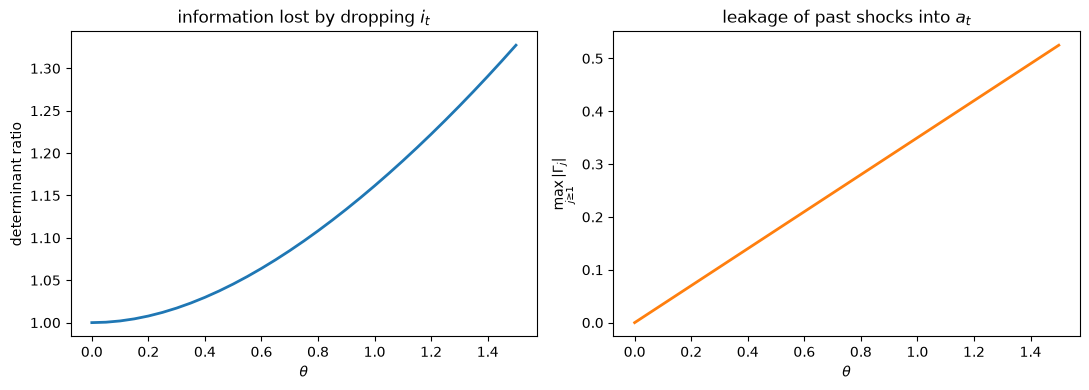

at theta = 0:   ratio = 1.000000, leakage = 1.11e-16
at theta = 1:   ratio = 1.1614, leakage = 0.3500


In [18]:
E = np.zeros((3, 3))
E[0, 2], E[1, 2] = -0.35, 0.25

thetas = np.linspace(0, 1.5, 31)
det_ratio, leak = [], []
for th in thetas:
    mod = VARSubsystem([A_exog + th * E], V3, S_gpi)
    Om = mod.innovation_cov()
    det_ratio.append(np.linalg.det(Om)
                     / np.linalg.det(S_gpi @ V3 @ S_gpi.T))
    leak.append(np.abs(mod.innovation_map(40)[1:]).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(thetas, det_ratio, lw=2)
axes[0].set(xlabel=r'$\theta$', ylabel='determinant ratio',
            title='information lost by dropping $i_t$')
axes[1].plot(thetas, leak, lw=2, color='C1')
axes[1].set(xlabel=r'$\theta$', ylabel=r'$\max_{j \geq 1} |\Gamma_j|$',
            title='leakage of past shocks into $a_t$')
for ax in axes:
    ax.axhline(ax.get_ylim()[0], color='k', lw=0.6)
fig.tight_layout()
plt.show()

print(f'at theta = 0:   ratio = {det_ratio[0]:.6f}, leakage = {leak[0]:.2e}')
print(f'at theta = 1:   ratio = {det_ratio[20]:.4f}, leakage = {leak[20]:.4f}')

两条曲线都从各自的最小值开始，泄漏量恰好为零，行列式之比恰好为一。

这正是 {prf:ref}`vs_prop_blockexog`：在 $\theta = 0$ 处，利率并不格兰杰因果地
影响 $(g, \pi)$，因此即使其新息与其他新息同期相关，剔除它也不会带来任何代价。

随着反馈强度的增强，两种度量都会上升。

```{solution-end}
```

```{exercise-start}
:label: vs_ex2
```

回到二元系统，但将 $A_1$ 和 $A_2$ 替换为单个矩阵

$$
A_1 = \begin{pmatrix} 0.5 & 0.6 \\ 0 & \rho_z \end{pmatrix},
\qquad V = I_2 ,
$$

从而由 $\rho_z$ 控制被剔除变量 $z$ 的持续性。

只观测 $r$，针对 $\rho_z \in \{0.2, 0.5, 0.75, 0.9, 0.95, 0.99\}$ 报告

1. 预测误差方差 $\Omega$，
2. 需要多少个滞后阶才能使 $\sum_{j > p} |B_j| < 10^{-3}$。

一个持续性很强的被剔除变量会对计量经济学家应当拟合的向量自回归产生什么影响？

```{exercise-end}
```

```{solution-start} vs_ex2
:class: dropdown
```

下面给出一种解法：

In [19]:
print(' rho_z    Omega    lags needed')
for rho_z in [0.2, 0.5, 0.75, 0.9, 0.95, 0.99]:
    mod = VARSubsystem([np.array([[0.5, 0.6], [0.0, rho_z]])],
                       np.eye(2), np.array([[1.0, 0.0]]))
    B = mod.var_coefficients(400)
    tails = [np.abs(B[p:]).sum() for p in range(400)]
    p_need = next(p for p in range(400) if tails[p] < 1e-3)
    print(f' {rho_z:5.2f}   {mod.innovation_cov()[0, 0]:6.4f}      {p_need:3d}')

 rho_z    Omega    lags needed
  0.20   1.3708        3
  0.50   1.4359        5
  0.75   1.5625        5
  0.90   1.6910        7
  0.95   1.7454        8
  0.99   1.7937        8


两列数值都随着 $\rho_z$ 的增大而增大。

一个持续性很强的被剔除变量既会推高预测误差方差，也会延长自回归所需要的滞后阶数，
因为计量经济学家必须回溯得更久，才能从 $r$ 的历史中提取出关于 $z$ 的同等信息量。

因此，一个滞后阶数过少的经验向量自回归，在被遗漏变量持续性最强的地方，
表现将会最差。

```{solution-end}
```

```{exercise-start}
:label: vs_ex3
```

系数 $B_j$ 是总体对象。

对例1中的二元系统模拟 $T = 200{,}000$ 个观测值，只保留 $r_t$，
并用普通最小二乘法拟合阶数为 $p = 1, 2, 4, 8$ 的有限阶自回归。

将估计结果与 $B_1, \ldots, B_p$ 进行比较，并将残差方差与 $\Omega$ 进行比较。

哪个阶数太短？拟合过短的滞后阶数会对第一个系数产生什么影响？

```{exercise-end}
```

```{solution-start} vs_ex3
:class: dropdown
```

下面给出一种解法：

In [20]:
Y_big, _ = mod_r.simulate(200_000, seed=3)
r_series = Y_big[:, 0]
B_pop = mod_r.var_coefficients(8)[:, 0, 0]

for p in [1, 2, 4, 8]:
    X = np.column_stack([r_series[p - 1 - l:len(r_series) - 1 - l]
                         for l in range(p)])
    zz = r_series[p:]
    b_hat = np.linalg.lstsq(X, zz, rcond=None)[0]
    resid = zz - X @ b_hat
    print(f'p = {p}')
    print(f'   OLS        {np.round(b_hat, 4)}')
    print(f'   population {np.round(B_pop[:p], 4)}')
    print(f'   residual variance {resid.var():.4f}   Omega {mod_r.innovation_cov()[0, 0]:.4f}')

p = 1
   OLS        [0.8179]
   population [0.7231]
   residual variance 1.6037   Omega 1.5786
p = 2
   OLS        [0.7201 0.1196]
   population [0.7231 0.1212]
   residual variance 1.5807   Omega 1.5786
p = 4
   OLS        [ 0.7207  0.1238 -0.0036 -0.0025]
   population [ 0.7231  0.1212 -0.0056  0.0007]
   residual variance 1.5807   Omega 1.5786
p = 8
   OLS        [ 0.7207  0.1238 -0.0035 -0.0022 -0.0019 -0.0011  0.003   0.0003]
   population [ 0.7231  0.1212 -0.0056  0.0007 -0.0001 -0.     -0.     -0.    ]
   residual variance 1.5806   Omega 1.5786


AR(1) 阶数太短。

它的单个系数被大幅抬高，远超 $B_1$，因为它必须替代被遗漏的第二个滞后项发挥作用，
而其残差方差也超过了 $\Omega$。

从 $p = 2$ 开始，估计值就能跟上总体系数，残差方差也稳定在 $\Omega$ 附近，
这与上文的发现一致：在本例中，$B_j$ 在超过第二个滞后阶之后就变得可以忽略不计。

```{solution-end}
```